# Q2 (Part 1) — Genetic Algorithm: Maximize f(x) = x^2

**Aim:** Maximize $f(x) = x^2$ for $0 \le x \le 31$ using 5-bit binary chromosomes.

**Algorithm**
- Initialize population (chromosomes).
- Decode chromosomes and compute fitness $f(x) = x^2$.
- Compute selection probability and expected/actual count (roulette wheel).
- Build the mating pool.
- Apply single-point crossover.
- Apply mutation (bit-flip) with a small probability.
- Form the new population; repeat until a stopping/convergence criterion is met.
- Return the best solution found.

## Key Parameter Settings

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Objective function ---
def f(x):
    return x**2

def decode(chromosome: str) -> int:
    return int(chromosome, 2)

# --- Key parameters ---
INIT_POPULATION = ['01100', '11001', '00101', '10011']
CHROM_LEN   = 5
POP_SIZE    = 4
GENERATIONS = 30
MUTATION_RATE = 0.02
DOMAIN = (0, 31)

pd.set_option('display.max_columns', None)
print(f"Objective       : f(x) = x^2, domain {DOMAIN}")
print(f"Chromosome length: {CHROM_LEN} bits")
print(f"Population size  : {POP_SIZE}")
print(f"Generations      : {GENERATIONS}")
print(f"Mutation rate    : {MUTATION_RATE}")

Objective       : f(x) = x^2, domain (0, 31)
Chromosome length: 5 bits
Population size  : 4
Generations      : 30
Mutation rate    : 0.02


## Step 1 — Initial Population, Fitness, Selection (hand-worked, Generation 1)

In [2]:
x_values = [decode(c) for c in INIT_POPULATION]
fitness = [f(x) for x in x_values]
total_fitness, avg_fitness = sum(fitness), sum(fitness) / len(fitness)

gen1 = pd.DataFrame({
    'String No.': range(1, 5), 'Chromosome': INIT_POPULATION, 'x': x_values, 'f(x)=x^2': fitness,
    'Probability': np.round([fit / total_fitness for fit in fitness], 3),
    'Expected Count': np.round([fit / avg_fitness for fit in fitness], 3),
    'Actual Count': [1, 2, 0, 1]
})
print(f"Sum f(x) = {total_fitness}, Average f(x) = {avg_fitness}, Max f(x) = {max(fitness)}")
gen1

Sum f(x) = 1155, Average f(x) = 288.75, Max f(x) = 625


,String No.,Chromosome,x,f(x)=x^2,Probability,Expected Count,Actual Count
0,1,01100,12,144,0.125,0.499,1
1,2,11001,25,625,0.541,2.165,2
2,3,00101,5,25,0.022,0.087,0
3,4,10011,19,361,0.313,1.250,1


## Core Algorithm (function definitions)

In [3]:
def crossover(parent_a: str, parent_b: str, site: int):
    return parent_a[:site] + parent_b[site:], parent_b[:site] + parent_a[site:]

def mutate(chromosome: str, rate: float, rng: random.Random) -> str:
    bits = list(chromosome)
    for i in range(len(bits)):
        if rng.random() < rate:
            bits[i] = '1' if bits[i] == '0' else '0'
    return ''.join(bits)

def roulette_select(population, fitnesses, rng: random.Random):
    return rng.choices(population, weights=fitnesses, k=1)[0]

def genetic_algorithm(init_population, decode_fn, fitness_fn, generations, mutation_rate,
                       chrom_len, rng=None, verbose_every=5, patience=6):
    rng = rng or random.Random()
    population = list(init_population)
    history = []
    best_x, best_f = None, float('-inf')
    stall = 0

    for gen in range(1, generations + 1):
        x_vals = [decode_fn(c) for c in population]
        fit_vals = [fitness_fn(x) for x in x_vals]
        gen_best_idx = int(np.argmax(fit_vals))

        if fit_vals[gen_best_idx] > best_f:
            best_f, best_x = fit_vals[gen_best_idx], x_vals[gen_best_idx]
            stall = 0
        else:
            stall += 1

        history.append({"Generation": gen, "Best x": x_vals[gen_best_idx],
                         "Best f(x)": fit_vals[gen_best_idx], "Avg f(x)": round(np.mean(fit_vals), 3)})

        if verbose_every and gen % verbose_every == 0:
            print(f"Generation {gen:3d} | Best x = {x_vals[gen_best_idx]:2d} | "
                  f"Best f(x) = {fit_vals[gen_best_idx]:4d} | Avg f(x) = {np.mean(fit_vals):.2f}")

        if best_x == 2**chrom_len - 1 or stall >= patience:
            break

        mating_pool = [roulette_select(population, fit_vals, rng) for _ in range(len(population))]
        new_population = []
        for i in range(0, len(mating_pool) - 1, 2):
            c1, c2 = crossover(mating_pool[i], mating_pool[i + 1], rng.randint(1, chrom_len - 1))
            new_population += [mutate(c1, mutation_rate, rng), mutate(c2, mutation_rate, rng)]
        if len(new_population) < len(population):
            new_population.append(mutate(mating_pool[-1], mutation_rate, rng))
        population = new_population

    return best_x, best_f, history

## Program Execution — Full run (repeated until convergence)

In [4]:
best_x, best_f, history = genetic_algorithm(
    INIT_POPULATION, decode, f, GENERATIONS, MUTATION_RATE, CHROM_LEN, rng=random.Random(1)
)

print("\nExecution Status: Successfully Executed")
print(f"Final Optimal Solution : x* = {best_x}")
print(f"Maximum Function Value : f(x*) = {best_f}")

hist_df = pd.DataFrame(history)
hist_df

Generation   5 | Best x = 27 | Best f(x) =  729 | Avg f(x) = 729.00

Execution Status: Successfully Executed
Final Optimal Solution : x* = 31
Maximum Function Value : f(x*) = 961


,Generation,Best x,Best f(x),Avg f(x)
0,1,25,625,288.75
1,2,27,729,501.00
2,3,27,729,501.00
3,4,27,729,619.00
4,5,27,729,729.00
5,6,27,729,679.00
6,7,31,961,737.00


## Convergence Graph

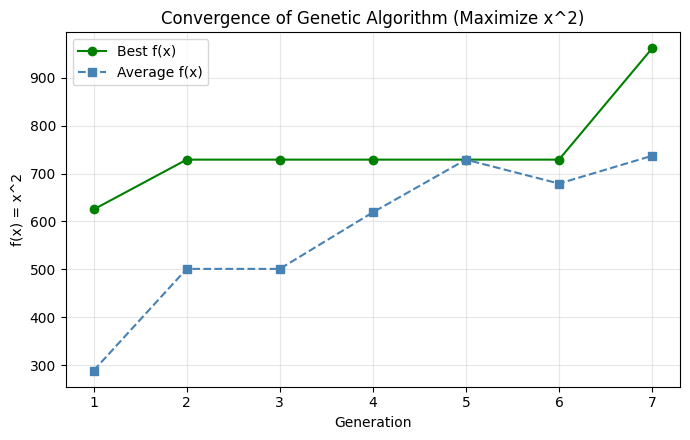

In [5]:
plt.figure(figsize=(7, 4.5))
plt.plot(hist_df['Generation'], hist_df['Best f(x)'], 'o-', color='green', label='Best f(x)')
plt.plot(hist_df['Generation'], hist_df['Avg f(x)'], 's--', color='steelblue', label='Average f(x)')
plt.xlabel('Generation')
plt.ylabel('f(x) = x^2')
plt.title('Convergence of Genetic Algorithm (Maximize x^2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Parameter Modification

In [6]:
param_tests = [
    ("Population Size", 4, 8, {"init_population": ['01100', '11001', '00101', '10011',
                                                     '00000', '11111', '01010', '10101']}),
    ("Mutation Rate", MUTATION_RATE, 0.10, {"mutation_rate": 0.10}),
    ("Generations", GENERATIONS, 10, {"generations": 10}),
    ("Initial Population", "given", "randomised", {"init_population": None}),
]

rows = []
for label, orig_val, mod_val, override in param_tests:
    base = dict(init_population=INIT_POPULATION, decode_fn=decode, fitness_fn=f,
                generations=GENERATIONS, mutation_rate=MUTATION_RATE, chrom_len=CHROM_LEN,
                verbose_every=0)
    _, orig_f, _ = genetic_algorithm(rng=random.Random(1), **base)

    mod_kwargs = dict(base)
    if override.get("init_population", "unset") is None:
        mod_kwargs["init_population"] = [''.join(random.Random(7).choice('01') for _ in range(CHROM_LEN))
                                          for _ in range(4)]
        del override["init_population"]
    mod_kwargs.update(override)
    _, mod_f, _ = genetic_algorithm(rng=random.Random(1), **mod_kwargs)

    rows.append({"Parameter": label, "Original Value": orig_val, "Modified Value": mod_val,
                 "Original Result f(x)": orig_f, "Modified Result f(x)": mod_f})

param_table = pd.DataFrame(rows)
param_table.insert(0, "S. No.", range(1, len(param_table) + 1))
param_table

,S. No.,Parameter,Original Value,Modified Value,Original Result f(x),Modified Result f(x)
0,1,Population Size,4,8,961,961
1,2,Mutation Rate,0.02,0.1,961,841
2,3,Generations,30,10,961,961
3,4,Initial Population,given,randomised,961,961


## Conclusion

- Starting from the given initial population, the GA (roulette-wheel selection, single-point crossover, bit-flip mutation) converges toward the true maximum $f(31) = 961$ within a few generations.
- Both the best and average fitness improve steadily across generations, as shown in the convergence graph.